In [1]:
%load_ext autoreload
%autoreload 2
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import os
import argparse
import os
import sys
import numpy as np
from tqdm import tqdm
import torch
from matplotlib import pyplot as plt

sys.path.append(os.path.abspath('../src'))
from utils.data_utils import split_dataset, split_indices
from dataset.placenta import PlacentaDatasetHypergraph
from dataset.extend import ExtendedDataset
from dataset.mibi import MIBIDataset, MIBISubsetHypergraph
from utils.seed import seed_everything
from models.hypergraph_scattering import HypergraphScatteringNet
from train import prepare_dataloaders

In [2]:
cell_protein_df = pd.read_csv('../data/MIBI/raw/cell_protein_data.csv')
patient_df = pd.read_csv('../data/MIBI/raw/patient_info.csv')

In [3]:
from argparse import Namespace

args = Namespace(
    dataset='mibi',
    data_folder='../data/MIBI/patchified_all_genes',
    train_val_test_ratio='6:2:2',
    desired_batch_size=16,
    batch_size=1,
    k_hop=1,
    num_workers=4,
    max_epochs=50,
    max_training_iters=512,
    max_validation_iters=256,
    learning_rate=1e-2,
    random_seed=1,
)

In [4]:
import argparse
import os
import sys
import math
import phate
import scprep
import numpy as np
from tqdm import tqdm
import torch
from matplotlib import pyplot as plt
from sklearn.preprocessing import normalize


@torch.no_grad()
def save_test_set_embeddings(model, test_loader, device, embedding_save_path):
    hyperedge_emb_arr, hyperedge_label_arr, hyperedge_gene_expression_arr = None, None, None
    hypergraph_emb_arr, hypergraph_label_arr, hypergraph_gene_expression_arr = None, None, None

    for data_item in test_loader:
        print(data_item)
        data_item = data_item.to(device)
        y_true = torch.Tensor(data_item.y).long().to(device)
        embedding = model(
            x=data_item.x,
            hyperedge_index=data_item.edge_index,
            hyperedge_attr=data_item.edge_attr,
            batch=data_item.batch,
            return_wavelet_embeddings=True)

        hyperedge_emb = embedding.cpu().detach().numpy()
        # `hyperedge_emb.shape[0]` is number of hyperedges. Repeat the label for each hyperedge.
        hyperedge_label = y_true.cpu().detach().numpy().reshape(-1, 1).repeat(hyperedge_emb.shape[0], axis=0)
        hyperedge_gene_expression = data_item.x.cpu().detach().numpy()
        hypergraph_emb = embedding.cpu().detach().numpy().mean(axis=0, keepdims=True)
        hypergraph_label = y_true.cpu().detach().numpy().reshape(-1, 1)
        hypergraph_gene_expression = data_item.x.cpu().detach().numpy().mean(axis=0, keepdims=True)

        if hypergraph_emb_arr is None:
            hyperedge_emb_arr = hyperedge_emb
            hyperedge_label_arr = hyperedge_label
            hyperedge_gene_expression_arr = hyperedge_gene_expression
            hypergraph_emb_arr = hypergraph_emb
            hypergraph_label_arr = hypergraph_label
            hypergraph_gene_expression_arr = hypergraph_gene_expression
        else:
            hyperedge_emb_arr = np.concatenate((hyperedge_emb_arr, hyperedge_emb), axis=0)
            hyperedge_label_arr = np.concatenate((hyperedge_label_arr, hyperedge_label), axis=0)
            hyperedge_gene_expression_arr = np.concatenate((hyperedge_gene_expression_arr, hyperedge_gene_expression), axis=0)
            hypergraph_emb_arr = np.concatenate((hypergraph_emb_arr, hypergraph_emb), axis=0)
            hypergraph_label_arr = np.concatenate((hypergraph_label_arr, hypergraph_label), axis=0)
            hypergraph_gene_expression_arr = np.concatenate((hypergraph_gene_expression_arr, hypergraph_gene_expression), axis=0)

    with open(embedding_save_path, 'wb+') as f:
        np.savez(f,
                 hyperedge_emb_arr=hyperedge_emb_arr, hyperedge_label_arr=hyperedge_label_arr, hyperedge_gene_expression_arr=hyperedge_gene_expression_arr,
                 hypergraph_emb_arr=hypergraph_emb_arr, hypergraph_label_arr=hypergraph_label_arr, hypergraph_gene_expression_arr=hypergraph_gene_expression_arr)
    return

def visualize_test_set_embeddings(embedding_save_path, class_map, gene_list, hyperedge_sampling_rate: float = 0.1):
    with open(embedding_save_path, 'rb') as f:
        npzfile = np.load(f)
        hyperedge_emb_arr = npzfile['hyperedge_emb_arr']
        hyperedge_label_arr = npzfile['hyperedge_label_arr']
        hyperedge_gene_expression_arr = npzfile['hyperedge_gene_expression_arr']
        hypergraph_emb_arr = npzfile['hypergraph_emb_arr']
        hypergraph_label_arr = npzfile['hypergraph_label_arr']
        hypergraph_gene_expression_arr = npzfile['hypergraph_gene_expression_arr']

    # NOTE: Plot visualization where each node is a hypergraph (figure 1) or a hyperedge (figure 2).
    for entity_name, fig_title, embedding_label_expression in \
        zip(['hypergraph', 'hyperedge'],
            ['Each node is a hypergraph.', 'Each node is a hyperedge.'],
            [(hypergraph_emb_arr, hypergraph_label_arr, hypergraph_gene_expression_arr),
             (hyperedge_emb_arr, hyperedge_label_arr, hyperedge_gene_expression_arr)]):

        embedding_arr, label_arr, gene_expression_arr = embedding_label_expression

        if entity_name == 'hyperedge':
            if args.dataset == 'placenta':
                if '_' in gene_list[0]:
                    gene_name_list = [item.split('_')[1] for item in gene_list]
                else:
                    gene_name_list = gene_list
                # plot_histogram_for_genes(gene_name_list, gene_expression_arr, ['FGF2', 'FGFR1', 'FN1', 'KRT8'])
            else:
                gene_name_list = gene_list

        # Subsample the hyperedges, otherwise it gives OOM.
        if entity_name == 'hyperedge' and len(embedding_arr) > 1e6 and hyperedge_sampling_rate is not None:
            sampled_indices = np.random.choice(len(embedding_arr), size=int(hyperedge_sampling_rate * len(embedding_arr)))
            embedding_arr = embedding_arr[sampled_indices, :]
            label_arr = label_arr[sampled_indices, :]
            gene_expression_arr = gene_expression_arr[sampled_indices, :]

        phate_op = phate.PHATE(random_state=args.random_seed, n_jobs=args.num_workers, verbose=True)
        data_phate = phate_op.fit_transform(normalize(embedding_arr, axis=1))

        fig = plt.figure(figsize=(12, 8))
        for class_idx, class_name in class_map.items():
            ax = fig.add_subplot(2, len(class_map.items()), class_idx + 1)
            color_arr = label_arr == class_idx
            scprep.plot.scatter2d(
                data_phate,
                c=color_arr,
                cmap='coolwarm',
                ax=ax,
                title=class_name,
                xticks=False,
                yticks=False,
                label_prefix='PHATE',
                fontsize=10,
                s=5,
                alpha=0.5)
        fig.suptitle(fig_title, fontsize=20)
        fig.tight_layout(pad=2)
        fig.savefig(os.path.join(os.path.dirname(embedding_save_path), entity_name + '_embeddings.png'))

        # meld_op = meld.MELD(random_state=args.random_seed, n_jobs=args.num_workers, verbose=True)
        # sample_densities = meld_op.fit_transform(normalize(embedding_arr, axis=1), sample_labels=label_arr)
        # sample_likelihoods = meld.utils.normalize_densities(sample_densities)
        for class_idx, class_name in class_map.items():
            ax = fig.add_subplot(2, len(class_map.items()), len(class_map.items()) + class_idx + 1)
            color_arr = class_idx
            scprep.plot.scatter2d(
                data_phate,
                c=color_arr,
                cmap='coolwarm',
                ax=ax,
                title=class_name+' (MELD)',
                xticks=False,
                yticks=False,
                label_prefix='PHATE',
                fontsize=10,
                s=5,
                alpha=0.5)
        fig.tight_layout(pad=2)
        fig.savefig(os.path.join(os.path.dirname(embedding_save_path), entity_name + '_embeddings.png'), dpi=300)
        plt.close(fig)

        # Auto-determine layout (rows x cols) to be roughly square
        num_plots = len(gene_list)
        if args.dataset == 'placenta':
            if '_' in gene_list[0]:
                gene_name_list = [item.split('_')[1] for item in gene_list]
            else:
                gene_name_list = gene_list
        else:
            gene_name_list = gene_list
        idx_sorted = np.argsort(gene_name_list)
        gene_indices_sorted = np.arange(len(gene_name_list))[idx_sorted]
        gene_name_list_sorted = np.array(gene_name_list)[idx_sorted]

        chunk_size = 25  # At most 25 subplots per figure.
        indices_by_chunk = [np.arange(num_plots)[i:i + chunk_size] for i in range(0, num_plots, chunk_size)]

        for chunk_idx, indices in enumerate(indices_by_chunk):
            num_subplots = len(indices)
            cols = math.ceil(math.sqrt(num_subplots))
            rows = math.ceil(num_subplots / cols)
            fig = plt.figure(figsize=(cols * 5, rows * 4))

            gene_indices_chunk = gene_indices_sorted[indices]
            gene_name_list_chunk = gene_name_list_sorted[indices]

            for subplot_idx, (gene_idx, gene_name) in enumerate(zip(gene_indices_chunk, gene_name_list_chunk)):

                gene_expression = gene_expression_arr[:, gene_idx][:, None]

                ax = fig.add_subplot(rows, cols, subplot_idx + 1)

                vmax = np.percentile(gene_expression, 90)
                if vmax == 0:
                    vmax = np.max(gene_expression)

                scprep.plot.scatter2d(
                    data_phate,
                    c=gene_expression,
                    cmap='coolwarm',
                    vmin=0,
                    vmax=vmax,
                    ax=ax,
                    title=gene_name,
                    xticks=False,
                    yticks=False,
                    label_prefix='PHATE',
                    colorbar=True,
                    fontsize=16,
                    s=5,
                    alpha=0.25)
                ax.set_axis_off()

            fig.tight_layout(pad=2)
            fig.savefig(os.path.join(os.path.dirname(embedding_save_path), entity_name + f'_gene_expressions_{str(chunk_idx).zfill(3)}.png'), dpi=100)
            plt.close(fig)

    return

def plot_histogram_for_genes(gene_name_list, gene_expression_arr, gene_names_to_plot) -> None:
    num_subplots = len(gene_names_to_plot)
    cols = math.ceil(math.sqrt(num_subplots))
    rows = math.ceil(num_subplots / cols)
    fig = plt.figure(figsize=(cols * 5, rows * 4))

    for subplot_idx, gene_name in enumerate(gene_names_to_plot):
        gene_index = np.argwhere(np.array(gene_name_list) == gene_name).item()
        gene_expression = gene_expression_arr[:, gene_index]

        ax = fig.add_subplot(rows, cols, subplot_idx + 1)
        ax.hist(gene_expression, bins=256, color='#00356B')
        ax.set_yscale('log')  # Apply log scale to the y-axis
        ax.set_title(gene_name)
        ax.set_ylabel('Count')
        ax.set_xlabel('Expression')

    fig.tight_layout(pad=2)
    fig.savefig(os.path.join(os.path.dirname(embedding_save_path), f'gene_expressions_histogram.png'), dpi=100)
    plt.close(fig)
    return


In [5]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the data.
train_loader, val_loader, test_loader, num_classes = prepare_dataloaders(args)

model = HypergraphScatteringNet(
    in_channels=64,
    hidden_channels=64,
    out_channels=num_classes,
    num_features=29,
    trainable_laziness=False,
    trainable_scales=True,
    activation=None,  # just get one layer of wavelet transform
    fixed_weights=True,
    layout=['hsm'],
    normalize='right',
    pooling='attention',
    scale_list=[0,1,2,4]
)
model.eval()
model.to(device)

model_save_path = os.path.join('/home/jcr222/workspace/hypergraphs/hypergraph-wavelets/results/mibi/dataset-mibi-patchified_all_genes_kHop-1_features-29_trainable_scales-False_seed-1/model.pt')
root_save_path = '/home/jcr222/workspace/hypergraphs/hypergraph-wavelets/results/mibi/dataset-mibi-patchified_all_genes_kHop-1_features-29_trainable_scales-False_seed-1'
embedding_save_path = os.path.join(root_save_path,'embedding.npz')
embedding_save_path


'/home/jcr222/workspace/hypergraphs/hypergraph-wavelets/results/mibi/dataset-mibi-patchified_all_genes_kHop-1_features-29_trainable_scales-False_seed-1/embedding.npz'

In [6]:
gene_list = test_loader.dataset.dataset.gene_list
class_map = test_loader.dataset.dataset.class_map
model.eval()
model.load_state_dict(torch.load(model_save_path, map_location=device, weights_only=True))
if not os.path.isfile(embedding_save_path):
    save_test_set_embeddings(model, test_loader, device, embedding_save_path)

/home/jcr222/.conda/envs/pyg_scatter/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [7]:
class_map

{0: 'PD', 1: 'SD', 2: 'PR', 3: 'CR'}

Calculating PHATE...
  Running PHATE on 1070 observations and 116 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...


    Calculated PCA in 0.21 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.10 seconds.
    Calculating affinities...
    Calculated affinities in 1.29 seconds.
  Calculated graph and diffusion operator in 1.61 seconds.
  Calculating optimal t...
    Automatically selected t = 27
  Calculated optimal t in 0.21 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.31 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 0.55 seconds.
Calculated PHATE in 2.68 seconds.


ValueError: Expected c of length 1070 or 1. Got 1

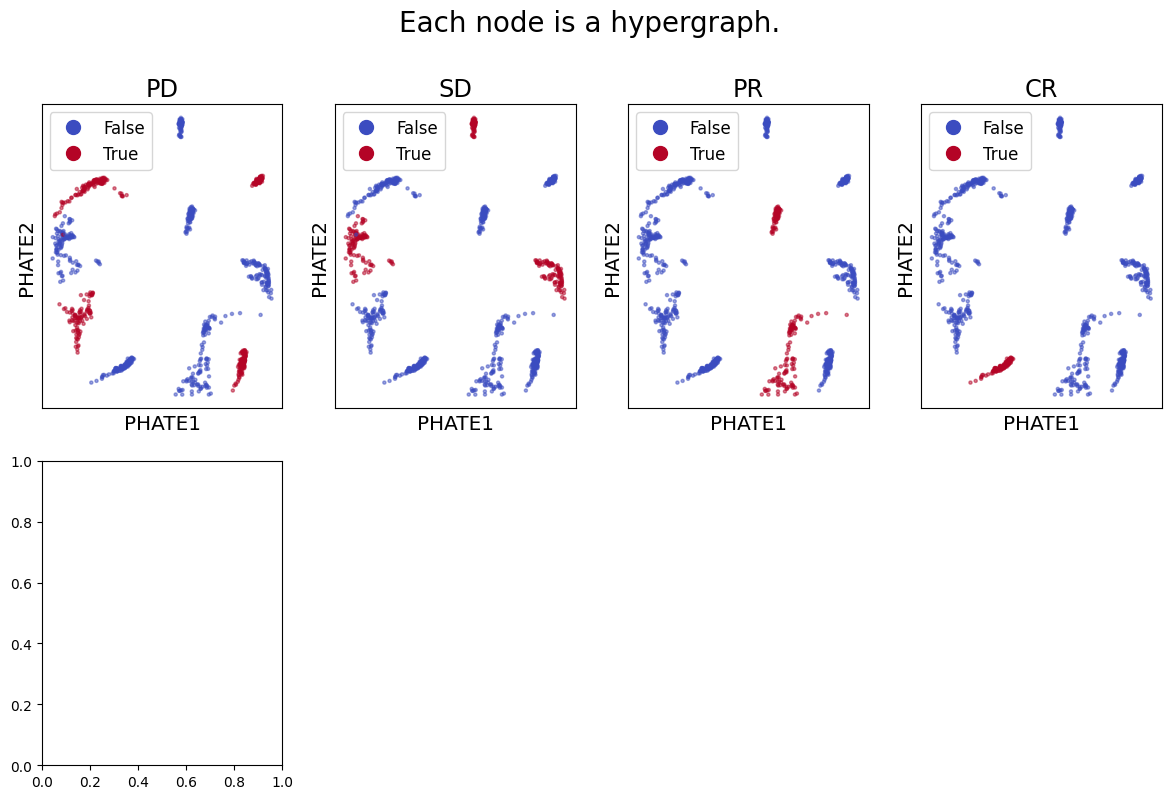

In [8]:
visualize_test_set_embeddings(embedding_save_path, class_map, gene_list=gene_list)

In [ ]:
patient_df['response_multi'].value_counts()

response_multi
SD    16
PD    15
PR    15
CR     8
Name: count, dtype: int64